In [2]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
data = {
    "Experience": [2,5,1,8,4,10,3,6,7,2],
    "TrainingHours": [40,60,20,80,50,90,30,70,75,25],
    "WorkingHours": [38,42,35,45,40,48,37,44,46,36],
    "Projects": [3,6,2,8,5,9,4,7,7,3],
    "Productivity": [62,78,55,88,72,92,65,82,85,60]
}

df = pd.DataFrame(data)
print(df)

   Experience  TrainingHours  WorkingHours  Projects  Productivity
0           2             40            38         3            62
1           5             60            42         6            78
2           1             20            35         2            55
3           8             80            45         8            88
4           4             50            40         5            72
5          10             90            48         9            92
6           3             30            37         4            65
7           6             70            44         7            82
8           7             75            46         7            85
9           2             25            36         3            60


In [5]:
X = df[["Experience", "TrainingHours", "WorkingHours", "Projects"]]
y = df["Productivity"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [8]:
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coeff_df)

         Feature  Coefficient
0     Experience    -0.263658
1  TrainingHours     0.272684
2   WorkingHours    -1.085511
3       Projects     4.885986


In [9]:
y_pred = model.predict(X_test)

print("Predictions:", y_pred)
print("Actual:", y_test.values)

Predictions: [81.04275534 76.93586698]
Actual: [85 78]


In [10]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 8.396082170603862
R2 Score: 0.3146055370935623


In [11]:
new_employee = np.array([[5, 65, 42, 6]])
# [Experience, TrainingHours, WorkingHours, Projects]

prediction = model.predict(new_employee)

print("Predicted Productivity:", prediction[0])

Predicted Productivity: 78.29928741092637


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [12]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Train R2:", train_score)
print("Test R2:", test_score)

Train R2: 0.9999147875547224
Test R2: 0.3146055370935623


In [13]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

print("Ridge Test Score:", ridge.score(X_test, y_test))

Ridge Test Score: 0.7178801309542799


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# For better visuals
sns.set()

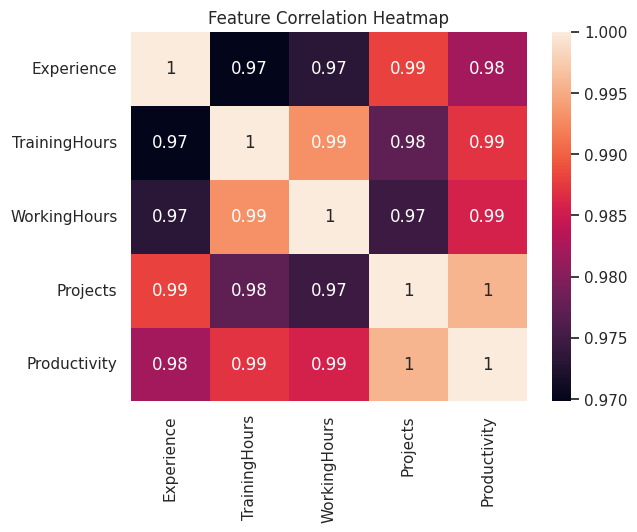

In [15]:
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

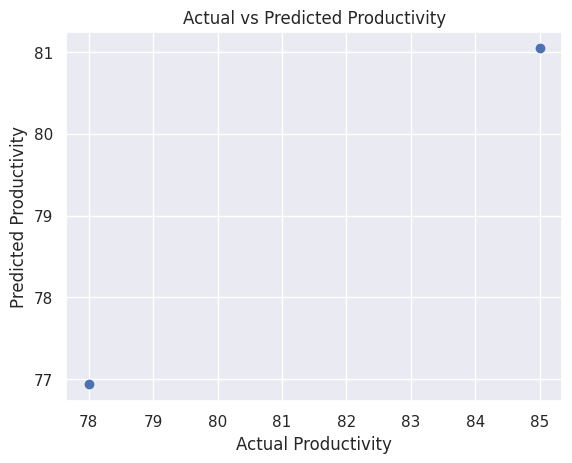

In [16]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Productivity")
plt.ylabel("Predicted Productivity")
plt.title("Actual vs Predicted Productivity")
plt.show()

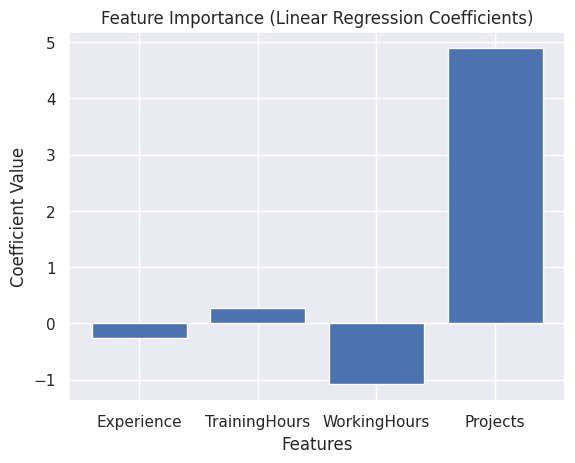

In [17]:
plt.figure()
plt.bar(X.columns, model.coef_)
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.show()